# Week 6 - Function 8 ((45DP, 8D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [1]:
import numpy as np
import torch
import gpytorch

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.stats.qmc import LatinHypercube

from utils.plotting_utils import (
    plot_8D_shap_analysis,
    plot_output_outliers,
    plot_nd_mean_uncertainty_slice
)

In [2]:
# ── GPyTorch utilities (shared across migrated notebooks) ──────────────────────

class MaternARD_ExactGP(gpytorch.models.ExactGP):
    def __init__(self, X, y, likelihood, n_dims, ls_prior=None):
        super().__init__(X, y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        ls_prior = ls_prior or gpytorch.priors.GammaPrior(3.0, 6.0)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5, ard_num_dims=n_dims,
                lengthscale_prior=ls_prior
            ),
            outputscale_prior=gpytorch.priors.GammaPrior(2.0, 0.15)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def fit_gpytorch_model(X_np, y_np, n_dims, noise=0.01, n_steps=300, lr=0.1, ls_prior=None):
    X_t = torch.tensor(X_np, dtype=torch.float64)
    y_t = torch.tensor(y_np, dtype=torch.float64)
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    likelihood.noise = noise
    model = MaternARD_ExactGP(X_t, y_t, likelihood, n_dims, ls_prior=ls_prior).double()
    likelihood = likelihood.double()
    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    losses = []
    for _ in range(n_steps):
        optimizer.zero_grad()
        loss = -mll(model(X_t), y_t)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    model.eval(); likelihood.eval()
    return model, likelihood, losses


def gp_predict(model, likelihood, X_np):
    """Drop-in replacement for sklearn GP.predict(X, return_std=True)."""
    X_t = torch.tensor(X_np, dtype=torch.float64)
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(X_t))
    return pred.mean.numpy(), pred.variance.sqrt().numpy()


def gp_converged_gpytorch(losses, min_loss_drop=0.1, max_final_loss=10.0):
    losses_arr = np.array(losses)
    loss_drop = losses_arr[0] - losses_arr[-1]
    converged = (not np.any(np.isnan(losses_arr))
                 and loss_drop >= min_loss_drop
                 and losses_arr[-1] < max_final_loss)
    return converged, {'loss_drop': loss_drop, 'final_loss': losses_arr[-1]}


# Plan
We now have ((45, 8)) — 45 data points, 8 dimensions, from `./data/week_6/function_8/`.

**Architecture**: Single GP (ARD Matern 2.5) with StandardScaler output, noise-dim dropping, and UCB acquisition.

**Key decisions** (carried forward):
- StandardScaler: well-behaved outputs (y ∈ [5.59, 9.85])
- Full 8D GP → ARD identifies noise dims → refit on active dims
- UCB kappa=3.846 (budget-aware: week 6/13)
- 100K LHS candidates in active-dim space; noise dims set to training mean

**Week 6 fixes:**
- **Noise detection recalibrated**: GammaPrior(3,6) (mean=0.5) suppresses all ls below ~2.0, so the old threshold (ls > 1e4) never fires. Fix: use a weaker ls prior (GammaPrior(1, 0.1), mean=10) for the identification step so noise dims can diverge if the data supports it. Then apply relative threshold: ls > mean + 2×std.
- **LHS restored**: 100K candidates when active space ≤ 6D. The 30K reduction was a consequence of the failed noise detection (forced to search 8D); with a proper 6D active space, 100K fits in memory.

**Steps:** Load data → Preprocessing → Full 8D GP (weak prior, ARD) → Feature selection → GP visualization (2D slices) → Acquisition → Report

# 1. Load data

In [3]:
X_train_raw = np.load(r"./data/week_6/function_8/inputs.npy")
y_train_raw = np.load(r"./data/week_6/function_8/outputs.npy")
print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")

Shape: X=(45, 8), y=(45,)
X range: [0.0034, 0.9989]
y range: [5.59e+00, 9.89e+00]


/opt/anaconda3/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


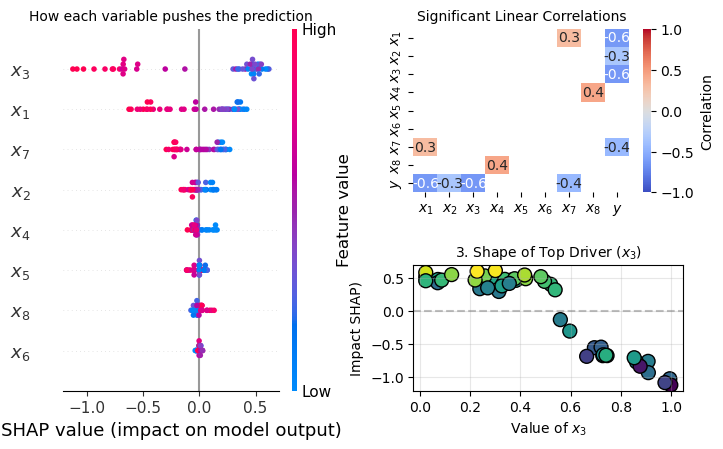

In [4]:
plot_8D_shap_analysis(X_train_raw, y_train_raw)

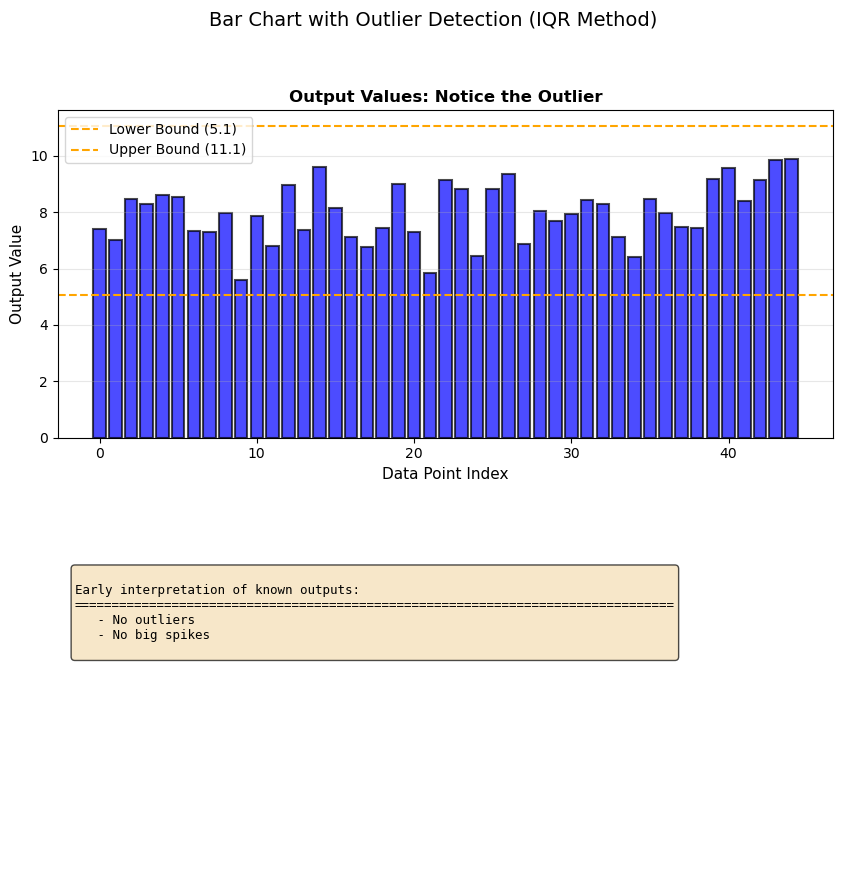

In [5]:
plot_output_outliers(X_train_raw, y_train_raw, "Bar Chart with Outlier Detection (IQR Method)", f"""
Early interpretation of known outputs:
{'='*80}
   - No outliers
   - No big spikes
""")

# 2. Preprocessing

No outliers, so StandardScaler is appropriate.

In [6]:
scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train_raw)
y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

print(f"Total points: {len(X_train)}")
print(f"Scaled y range: [{y_train.min():.2f}, {y_train.max():.2f}]")

Total points: 45
Scaled y range: [-2.32, 1.84]


# 3. GP with ARD (full 8D) — identify noise dimensions

We first fit on all 8 dims using a **weak length-scale prior** (GammaPrior(1, 0.1), mean=10) so noise dimensions can diverge to large ls values if the data supports it. The default GammaPrior(3,6) (mean=0.5) suppresses all ls below ~2.0, preventing noise dims from standing out. We then apply a **relative threshold** (ls > mean + 2×std) to identify noise dims robustly.

In [7]:
# Full 8D GP for noise-dim identification.
# Weak ls prior GammaPrior(1, 0.1) (mean=10) replaces the default GammaPrior(3,6) (mean=0.5).
# The tight default prior suppresses all ls below ~2.0, preventing noise dims from standing
# out. The weak prior allows noise dims to diverge to large ls if the data supports it.
weak_ls_prior = gpytorch.priors.GammaPrior(1.0, 0.1)  # mean=10, heavy tail
model_full, likelihood_full, losses_full = fit_gpytorch_model(
    X_train, y_train, n_dims=8, noise=0.01, n_steps=300, lr=0.1,
    ls_prior=weak_ls_prior)

conv_full, info_full = gp_converged_gpytorch(losses_full)
print(f"Full 8D GP (weak prior): final_loss={info_full['final_loss']:.4f}, loss_drop={info_full['loss_drop']:.4f}, converged={conv_full}")

learned_scales = model_full.covar_module.base_kernel.lengthscale.detach().numpy().ravel()
outputscale = model_full.covar_module.outputscale.item()
print(f"Outputscale: {outputscale:.4f}")

importance = 1.0 / learned_scales
importance_norm = importance / importance.sum() * 100

# Relative noise threshold: dims with ls > mean + 2*std are noise.
# More robust than absolute threshold (1e4) which fails when the prior suppresses large ls.
ls_mean_all = learned_scales.mean()
ls_std_all = learned_scales.std()
noise_threshold = ls_mean_all + 2 * ls_std_all
print(f"\nRelative threshold: mean={ls_mean_all:.4f} + 2×std={ls_std_all:.4f} = {noise_threshold:.4f}")

print(f"\nFeature Importance (from ARD length scales):")
print(f"{'Dim':<6} {'Length Scale':<20} {'Importance %':<15} {'Role'}")
print("=" * 80)
noise_dims = []
active_dims = []
sorted_dims = np.argsort(learned_scales)
for i in sorted_dims:
    if learned_scales[i] > noise_threshold:
        role = 'NOISE (drop)'
        noise_dims.append(i)
    elif learned_scales[i] > 10.0:
        role = 'weak'
        active_dims.append(i)
    else:
        role = 'IMPORTANT'
        active_dims.append(i)
    print(f"x{i+1:<5} {learned_scales[i]:<20.4f} {importance_norm[i]:<15.4f} {role}")

print(f"\nNoise dims (ls > {noise_threshold:.2f}): {['x'+str(d+1) for d in noise_dims]}")
print(f"Active dims: {['x'+str(d+1) for d in active_dims]}")

Full 8D GP (weak prior): final_loss=0.3920, loss_drop=1.0279, converged=True
Outputscale: 6.1027

Relative threshold: mean=5.2552 + 2×std=2.8902 = 11.0355

Feature Importance (from ARD length scales):
Dim    Length Scale         Importance %    Role
x3     2.3238               22.1818         IMPORTANT
x1     3.0020               17.1704         IMPORTANT
x7     3.1329               16.4529         IMPORTANT
x6     4.4104               11.6874         IMPORTANT
x2     4.4337               11.6260         IMPORTANT
x4     5.1443               10.0199         IMPORTANT
x5     8.0664               6.3902          IMPORTANT
x8     11.5279              4.4714          NOISE (drop)

Noise dims (ls > 11.04): ['x8']
Active dims: ['x3', 'x1', 'x7', 'x6', 'x2', 'x4', 'x5']


# 4. Feature selection — refit GP on active dims only

Drop noise dimensions and refit. This reduces the effective dimensionality and improves GP predictions.

In [8]:
n_active = len(active_dims)
X_train_active = X_train[:, active_dims]
print(f"Effective dimensionality: {n_active}D (dropped {len(noise_dims)} noise dims)")

if len(noise_dims) == 0:
    # No noise dims detected — the active GP would be identical to model_full.
    # Reuse it instead of running another 400-step training pass (which previously caused a kernel crash).
    print("No noise dims — reusing full 8D GP as acquisition model (no refit needed).")
    model, likelihood, losses = model_full, likelihood_full, losses_full
    converged, conv_info = conv_full, info_full
else:
    # Refit on active dims only (fewer dims → faster, better GP)
    model, likelihood, losses = fit_gpytorch_model(
        X_train_active, y_train, n_dims=n_active, noise=0.01, n_steps=400, lr=0.1)
    converged, conv_info = gp_converged_gpytorch(losses)

print(f"Active GP: final_loss={conv_info['final_loss']:.4f}, loss_drop={conv_info['loss_drop']:.4f}, converged={converged}")

# Feature importance within active dims
ls_active = model.covar_module.base_kernel.lengthscale.detach().numpy().ravel()
imp_active = 1.0 / ls_active
imp_active_norm = imp_active / imp_active.sum() * 100

print(f"\nActive dim importance:")
sorted_active = np.argsort(ls_active)
for j in sorted_active:
    orig_dim = active_dims[j]
    print(f"  x{orig_dim+1}: ls={ls_active[j]:.4f}, importance={imp_active_norm[j]:.1f}%")

# Determine plot/slider dims (within active space)
most_important_active = sorted_active[:2]
slider_active = sorted_active[2:]
dim_a_orig = active_dims[most_important_active[0]]
dim_b_orig = active_dims[most_important_active[1]]
slider_dims_orig = [active_dims[j] for j in slider_active]
print(f"\nPlotting dims: x{dim_a_orig+1}, x{dim_b_orig+1}")
print(f"Slider dims: {['x'+str(d+1) for d in slider_dims_orig]}")

Effective dimensionality: 7D (dropped 1 noise dims)
Active GP: final_loss=0.7397, loss_drop=0.2133, converged=True

Active dim importance:
  x3: ls=0.6738, importance=21.5%
  x1: ls=0.8740, importance=16.6%
  x7: ls=0.9376, importance=15.5%
  x2: ls=1.1686, importance=12.4%
  x4: ls=1.1914, importance=12.2%
  x6: ls=1.3182, importance=11.0%
  x5: ls=1.3338, importance=10.9%

Plotting dims: x3, x1
Slider dims: ['x7', 'x2', 'x4', 'x6', 'x5']


# 5. GP Visualization (2D slices)

Fix the 4 least important active dimensions at selected values and view contour plots of the 2 most important active dimensions. Two slices are shown: one at the spatial midpoint (all fixed dims = 0.5) and one at the current best point's coordinates.

=== Slice at midpoint (x7=0.5, x2=0.5, x4=0.5, x6=0.5, x5=0.5) ===


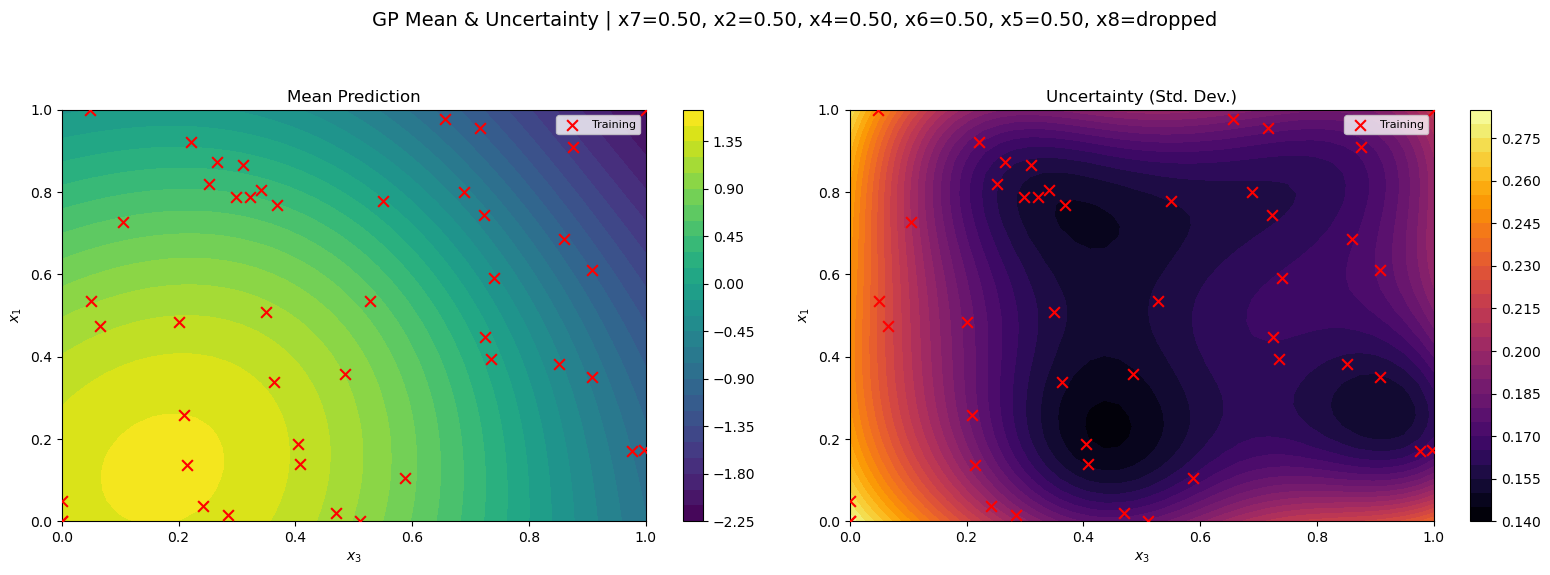


=== Slice at current best (x7=0.24, x2=0.12, x4=0.06, x6=0.43, x5=0.95) ===


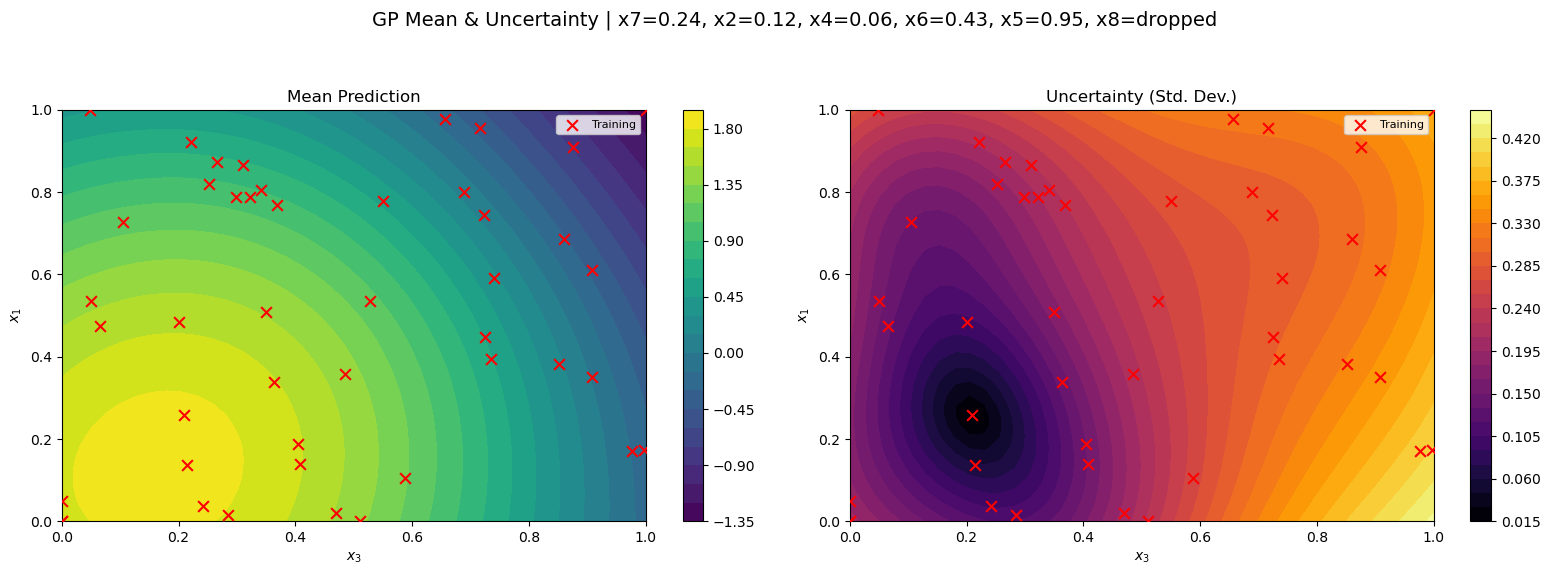

In [9]:
n_grid_2d = 40
x_plot_1 = np.linspace(0, 1, n_grid_2d)
x_plot_2 = np.linspace(0, 1, n_grid_2d)
X1_plot, X2_plot = np.meshgrid(x_plot_1, x_plot_2)

def plot_gp_slice(**kwargs):
    # Build grid in active-dim space
    grid_active = np.zeros((n_grid_2d * n_grid_2d, n_active))
    grid_active[:, most_important_active[0]] = X1_plot.ravel()
    grid_active[:, most_important_active[1]] = X2_plot.ravel()
    for j in slider_active:
        orig_dim = active_dims[j]
        grid_active[:, j] = kwargs[f'x{orig_dim+1}']

    mu, sigma = gp_predict(model, likelihood, grid_active)

    fixed_parts = [f'x{active_dims[j]+1}={kwargs[f"x{active_dims[j]+1}"]:.2f}' for j in slider_active]
    noise_parts = [f'x{d+1}=dropped' for d in noise_dims]
    fixed_info = ', '.join(fixed_parts + noise_parts)

    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu.reshape(n_grid_2d, n_grid_2d),
        sigma.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a_orig, dim2_idx=dim_b_orig,
        title_prefix='GP Mean & Uncertainty',
        fixed_info=fixed_info
    )

# Slice 1: all slider dims at midpoint
mid_kwargs = {f'x{active_dims[j]+1}': 0.5 for j in slider_active}
slider_names = [f'x{active_dims[j]+1}' for j in slider_active]
print(f"=== Slice at midpoint ({', '.join(f'{k}=0.5' for k in slider_names)}) ===")
plot_gp_slice(**mid_kwargs)

# Slice 2: best known point's active-dim values
best_idx = np.argmax(y_train_raw)
best_kwargs = {f'x{active_dims[j]+1}': float(X_train_active[best_idx, j]) for j in slider_active}
best_desc = ', '.join(f'{k}={v:.2f}' for k, v in best_kwargs.items())
print(f"\n=== Slice at current best ({best_desc}) ===")
plot_gp_slice(**best_kwargs)

# 6. Acquisition Function (UCB on LHS candidates)

LHS candidates in the active-dim space. 100K candidates when active space ≤ 6D (fits in memory); 30K fallback for full 8D if no noise dims are detected.

In [10]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

# LHS count scaled by active dimensionality to avoid OOM.
# 100K × 8D crashed the kernel; 30K × 8D was the safe fallback.
# With noise dims dropped: 100K for ≤6D (matches Week 5), 50K for 7D, 30K for full 8D.
if n_active <= 6:
    n_lhs = 100_000
elif n_active == 7:
    n_lhs = 50_000
else:
    n_lhs = 30_000

sampler = LatinHypercube(d=n_active, seed=42)
X_cand_active = sampler.random(n=n_lhs)

# GP predictions on candidates
mu_cand, sigma_cand = gp_predict(model, likelihood, X_cand_active)

# Budget-aware kappa: linear decay from 5.0 (week 1) to 2.0 (week 13)
WEEK = 6
kappa = 5.0 - ((WEEK - 1) / 13) * 3.0
print(f"kappa = {kappa:.4f} (week {WEEK}/13)")
print(f"LHS candidates: {n_lhs:,} in {n_active}D active space")

ucb_values = upper_confidence_bound(mu_cand, sigma_cand, kappa=kappa)

best_idx = np.argmax(ucb_values)
x_best_active = X_cand_active[best_idx]

# Reconstruct full 8D point: active dims from best candidate, noise dims at training mean
x_next_norm_full = np.zeros(8)
for j, orig_dim in enumerate(active_dims):
    x_next_norm_full[orig_dim] = x_best_active[j]
for d in noise_dims:
    x_next_norm_full[d] = X_train[:, d].mean()

x_next_orig = scaler_X.inverse_transform([x_next_norm_full])[0]

print(f"{'='*80}")
print(f"RECOMMENDED NEXT POINT (UCB, kappa={kappa:.2f}, {n_lhs:,} LHS in {n_active}D active space)")
print(f"{'='*80}")
print(f"  Input (original space): {np.array_str(x_next_orig, precision=6)}")

y_pred, y_std = gp_predict(model, likelihood, np.array([x_best_active]))
print(f"  GP prediction: {y_pred[0]:.4f} +/- {y_std[0]:.4f}")
print(f"  UCB value: {ucb_values[best_idx]:.4f}")

print(f"\nSanity check - is this a corner?")
for i in range(8):
    if i in noise_dims:
        print(f"  x{i+1} = {x_next_norm_full[i]:.4f} (noise, fixed at training mean)")
    else:
        at_boundary = x_next_norm_full[i] < 0.02 or x_next_norm_full[i] > 0.98
        print(f"  x{i+1} = {x_next_norm_full[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: {X_train_raw[np.argmax(y_train_raw)]} (y = {y_train_raw.max():.6f})")

X_next = x_next_orig
print(f"\nX_next = {X_next}")

# Machine-readable tag for get_submission.py
print(f"\nSUBMISSION: {'-'.join(f'{x:.6f}' for x in x_next_orig)}")

kappa = 3.8462 (week 6/13)
LHS candidates: 50,000 in 7D active space
RECOMMENDED NEXT POINT (UCB, kappa=3.85, 50,000 LHS in 7D active space)
  Input (original space): [0.121865 0.462219 0.108125 0.09996  0.184909 0.274514 0.036621 0.507323]
  GP prediction: 1.5104 +/- 0.3431
  UCB value: 2.8300

Sanity check - is this a corner?
  x1 = 0.1155 
  x2 = 0.4727 
  x3 = 0.0873 
  x4 = 0.1017 
  x5 = 0.1793 
  x6 = 0.2607 
  x7 = 0.0007 <-- BOUNDARY!
  x8 = 0.4915 (noise, fixed at training mean)

Current best: [0.260503 0.115282 0.227557 0.061515 0.939305 0.440824 0.26289  0.507323] (y = 9.888917)

X_next = [0.12186494 0.46221862 0.10812532 0.09996001 0.18490873 0.2745143
 0.03662096 0.50732275]

SUBMISSION: 0.121865-0.462219-0.108125-0.099960-0.184909-0.274514-0.036621-0.507323
